## 🏡 House Prices Prediction — ML Project

В данном проекте решается задача предсказания стоимости жилой недвижимости на основе датасета [**House Price Data, England & Wales, 1995 to 2019**](https://www.kaggle.com/datasets/dmaso01dsta/house-price-data-england-wales-1995-to-2019/). Мы выбрали из датасета файл 2019 года

В рамках проекта рассматриваются две постановки задачи:

* **Регрессия** — предсказание точной стоимости дома (`Price`)
* **Классификация** — разбиение домов на категории (дешёвые, средние, дорогие)

---

**План:**
1. Анализ данных (EDA)
2. Предобработка данных
3. Feature Engineering
4. Подготовка данных для моделей

---

### 1. Анализ данных (EDA)

In [97]:
# Импорты библиотек и настройка окружения notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [98]:
# Загрузка датасета
df = pd.read_csv('../data/pp-2019.csv', header=None)

df.columns = [
    'Transaction unique identifier', 'Price', 'date_of_transfer',
    'Postcode', 'Property_Type', 'Old/New', 'Duration',
    'PAON', 'SAON', 'Street', 'Locality',
    'Town/City', 'District', 'County',
    'PPD_Category_Type', 'Record_Status'
]
# PAON (Primary Addressable Object Name)
# SAON (Secondary Addressable Object Name)
# это британский формат адресов

df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
)

df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'], format='%Y-%m-%d %H:%M')

print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Строк: 864835, Столбцов: 16


In [99]:
# Типы данных и заполненность
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 864835 entries, 0 to 864834
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   transaction_unique_identifier  864835 non-null  str           
 1   price                          864835 non-null  int64         
 2   date_of_transfer               864835 non-null  datetime64[us]
 3   postcode                       860780 non-null  str           
 4   property_type                  864835 non-null  str           
 5   old/new                        864835 non-null  str           
 6   duration                       864835 non-null  str           
 7   paon                           864835 non-null  str           
 8   saon                           106850 non-null  str           
 9   street                         849709 non-null  str           
 10  locality                       328698 non-null  str           
 11  town/city  

In [100]:
# Базовая статистика по Price
print("Базовая статистика:")
df.describe()

Базовая статистика:


,price,date_of_transfer
count,864835.00,864835
mean,351500.29,2019-06-23 18:52:12.547595
min,1.00,2019-01-01 00:00:00
25%,148000.00,2019-03-29 00:00:00
50%,230000.00,2019-06-28 00:00:00
75%,355000.00,2019-09-13 00:00:00
max,542540820.00,2019-12-26 00:00:00
std,1997712.75,NaN


**std** очень высокое — значительный разброс и наличие выбросов.  
**min = 1.00** — явный выброс (нереальная цена; будет отфильтрован в предобработке).  
**max = 542 540 820** — экстремальный выброс (>542 млн £).  

In [101]:
print("Пропуски по столбцам:")
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

Пропуски по столбцам:


saon        757985
locality    536137
street       15126
postcode      4055
district       182
dtype: int64

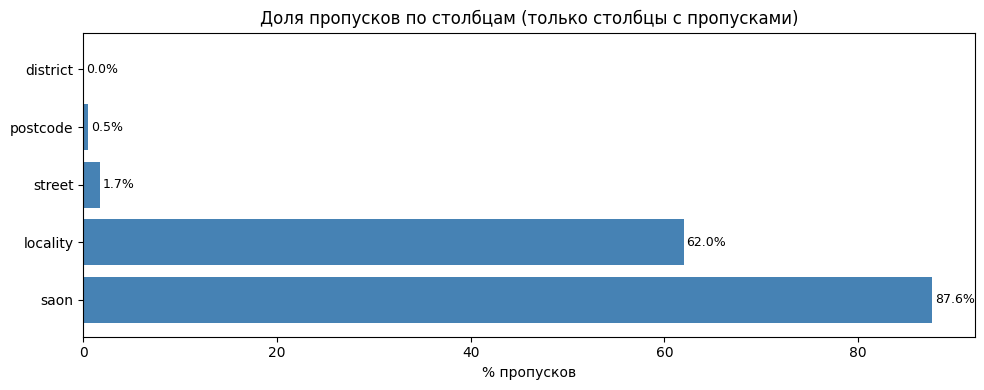

In [102]:
# Визуализация пропусков — % от общего числа строк
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_pct.index, missing_pct.values, color='steelblue')
ax.set_xlabel('% пропусков')
ax.set_title('Доля пропусков по столбцам (только столбцы с пропусками)')
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [103]:
# Дубликаты (без UUID)
df_dup = df.drop(columns=['transaction_unique_identifier'])
print(f"Дубликатов: {df_dup.duplicated().sum()}")

Дубликатов: 560


In [104]:
# Уникальные значения категориальных признаков
cat_cols = ['property_type', 'old/new', 'duration', 'ppd_category_type', 'record_status']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

property_type: <StringArray>
['T', 'S', 'D', 'F', 'O']
Length: 5, dtype: str
old/new: <StringArray>
['N', 'Y']
Length: 2, dtype: str
duration: <StringArray>
['F', 'L']
Length: 2, dtype: str
ppd_category_type: <StringArray>
['A', 'B']
Length: 2, dtype: str
record_status: <StringArray>
['A']
Length: 1, dtype: str


**Расшифровка категориальных признаков:**

- **Property_Type**: 
  - D = Detached — отдельно стоящий дом (полностью изолирован от соседей)
  - S = Semi-Detached — сдвоенный дом (соединён с одним соседом одной стеной)

    <img src="../imgs/Semi-Detached.jpg" width="500">

  - T = Terraced — рядный дом / таунхаус (соединён с соседями с двух сторон, кроме крайних)

    <img src="../imgs/Terraced.jpg" width="500">

  - F = Flats/Maisonettes — квартиры / мезонеты (квартиры в многоквартирных домах, включая двухуровневые квартиры с внутренней лестницей)

    <img src="../imgs/Maisonettes.jpg" width="500">

  - O = Other — прочие типы недвижимости (нестандартные объекты)

- **Old/New**: 
  - Y = новостройка
  - N = вторичный рынок

- **Duration**: 
  - F = Freehold — полное владение
  - L = Leasehold — долгосрочная аренда

- **PPD_Category_Type**:
  - A (Standard) — обычная рыночная продажа, стандартная сделка между покупателем и продавцом
  - B (Additional) — нестандартные случаи: передача между родственниками, корпоративные сделки и другие исключения

- **Record_Status**: *(используется для внутренней работы системы)*
  - A = Added
  - C = Changed
  - D = Deleted  

> **Примечание по `record_status`**: в данных за 2019 год присутствует только значение `A` (Added). Значения `C` (Changed) и `D` (Deleted) в этом файле отсутствуют. Колонка не несёт информации и будет удалена.

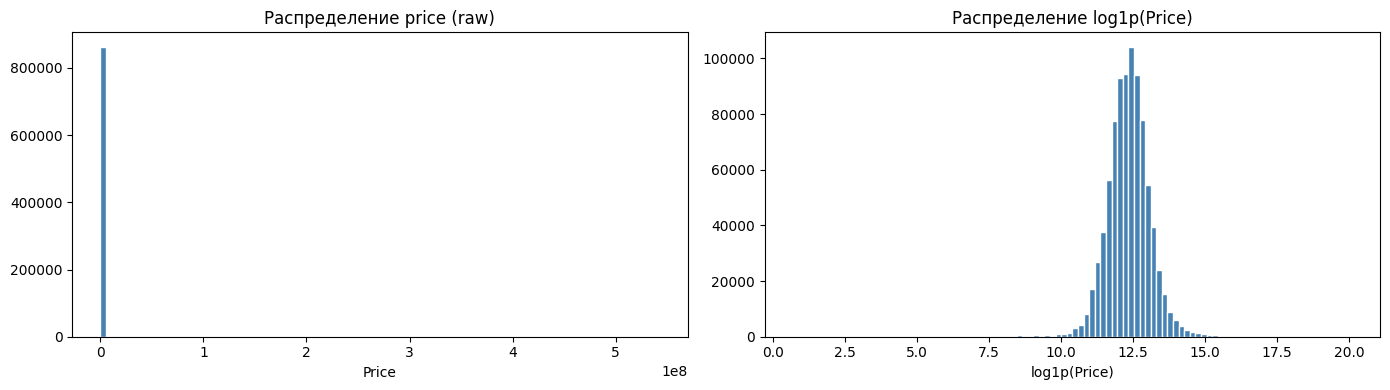

In [105]:
# Распределение цен (до удаления выбросов)
# 2 графика в одну строку с размерами 14 на 4
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение price (raw)')
axes[0].set_xlabel('Price')

axes[1].hist(np.log1p(df['price']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение log1p(Price)')
axes[1].set_xlabel('log1p(Price)')

plt.tight_layout()
plt.show()

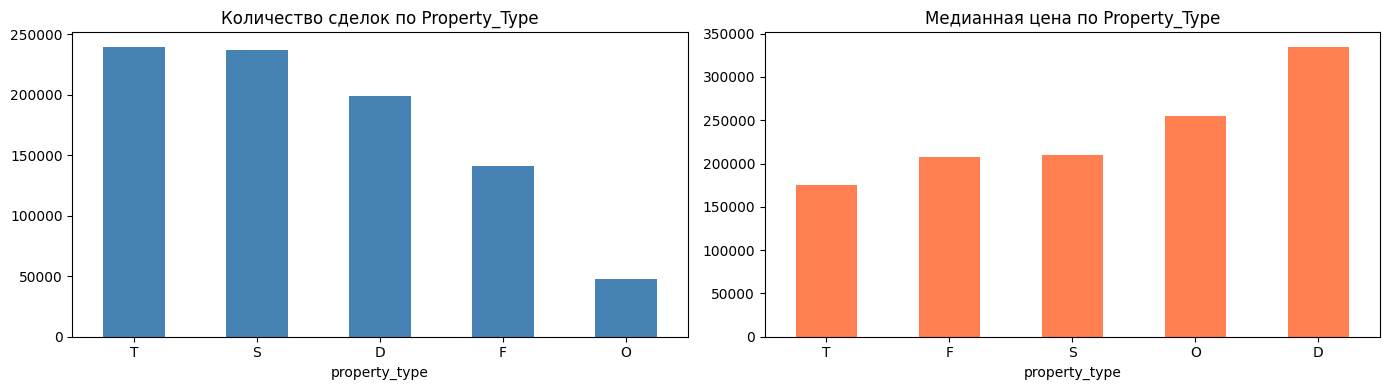

In [106]:
# Распределение по типу недвижимости
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['property_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Количество сделок по Property_Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df.groupby('property_type')['price'].median().sort_values().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Медианная цена по Property_Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

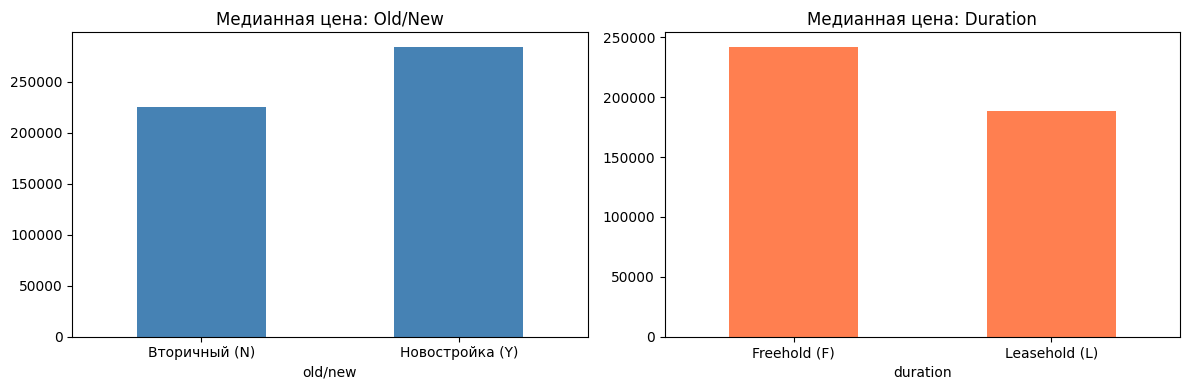

In [107]:
# Распределение по Old/New и Duration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('old/new')['price'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Медианная цена: Old/New')
axes[0].set_xticklabels(['Вторичный (N)', 'Новостройка (Y)'], rotation=0)

df.groupby('duration')['price'].median().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Медианная цена: Duration')
axes[1].set_xticklabels(['Freehold (F)', 'Leasehold (L)'], rotation=0)

plt.tight_layout()
plt.show()

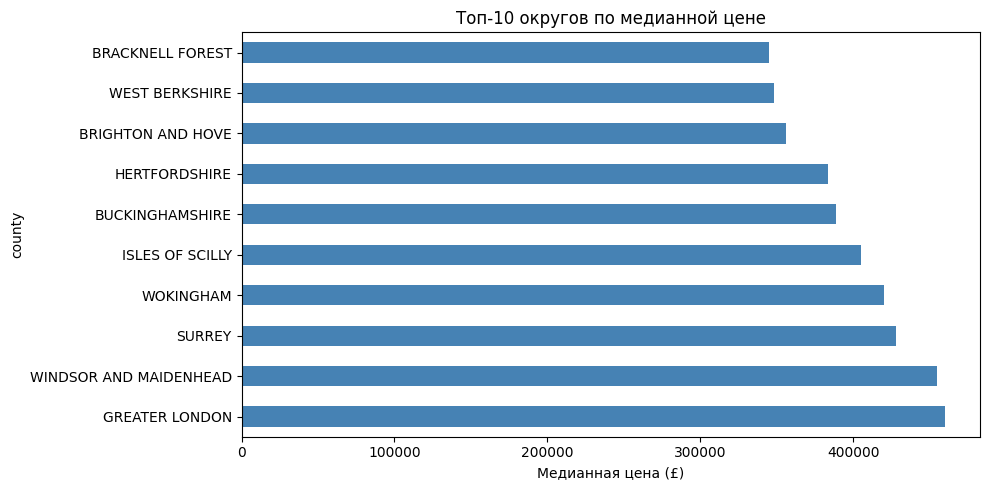

In [108]:
# Топ-10 округов по медианной цене
top_counties = df.groupby('county')['price'].median().sort_values(ascending=False).head(10)
top_counties.plot(kind='barh', color='steelblue', figsize=(10, 5))
plt.title('Топ-10 округов по медианной цене')
plt.xlabel('Медианная цена (£)')
plt.tight_layout()
plt.show()

---

### 2. Предобработка данных

In [109]:
# Удаление дубликатов (без учёта UUID — он уникален по определению)
print(f"До удаления дубликатов: {df.shape[0]} строк")

# Исправление: используем lowercase-имя колонки 'transaction_unique_identifier'
df = df.drop_duplicates(subset=df.columns.difference(['transaction_unique_identifier']))
print(f"После удаления дубликатов: {df.shape[0]} строк")

До удаления дубликатов: 864835 строк
После удаления дубликатов: 864275 строк


In [110]:
# Удаление выбросов по Price
# Нижняя граница: 1_000 £ (цены ниже нереальны для рыночной сделки)
# Верхняя граница: 99.9-й перцентиль (отсекаем самые экстремальные сделки)
price_low  = 1_000
price_high = df['price'].quantile(0.999)

print(f"Нижняя граница:         £{price_low:>12,.0f}")
print(f"Верхняя граница (99.9%):£{price_high:>12,.0f}")
print(f"Строк до фильтрации:  {df.shape[0]:>9}")

df = df[(df['price'] >= price_low) & (df['price'] <= price_high)]
print(f"Строк после фильтрации:{df.shape[0]:>9}")
print(f"Удалено:              {864835 - df.shape[0]:>9} строк")

Нижняя граница:         £       1,000
Верхняя граница (99.9%):£  12,500,000
Строк до фильтрации:     864275
Строк после фильтрации:   862701
Удалено:                   2134 строк


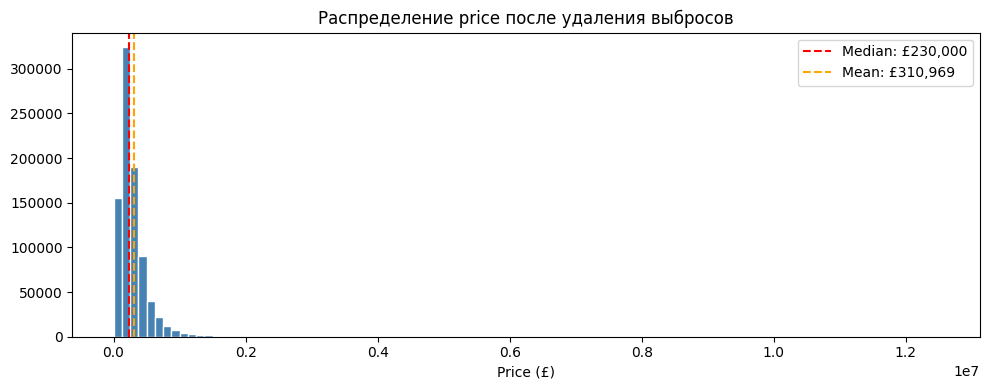

In [111]:
# Распределение price после удаления выбросов
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['price'], bins=100, color='steelblue', edgecolor='white')
ax.axvline(df['price'].median(), color='red', linestyle='--', label=f"Median: £{df['price'].median():,.0f}")
ax.axvline(df['price'].mean(),   color='orange', linestyle='--', label=f"Mean: £{df['price'].mean():,.0f}")
ax.set_title('Распределение price после удаления выбросов')
ax.set_xlabel('Price (£)')
ax.legend()
plt.tight_layout()
plt.show()

In [112]:
# Удаляем тип 'O' (Other) — слишком малочисленная и неоднородная категория
print(f"Строк с Property_Type = O: {(df['property_type'] == 'O').sum()}")
df = df[df['property_type'] != 'O']
print(f"Строк после удаления O: {df.shape[0]}")

Строк с Property_Type = O: 45768
Строк после удаления O: 816933


In [113]:
# Фильтруем только стандартные сделки (PPD_Category_Type = A)
# Тип B — нестандартные сделки (аукционы, внутрисемейные переводы и т.д.)
print(f"PPD_Category_Type распределение:\n{df['ppd_category_type'].value_counts()}")
df = df[df['ppd_category_type'] == 'A']
print(f"Строк после фильтрации по PPD=A: {df.shape[0]}")

PPD_Category_Type распределение:
ppd_category_type
A    731704
B     85229
Name: count, dtype: int64
Строк после фильтрации по PPD=A: 731704


In [114]:
# Удаляем не информативную колонку:
df = df.drop(columns=['record_status'])

In [115]:
# Обработка пропусков
# SAON (87% пропусков) — отсутствует у большинства объектов (есть только у квартир)
# Locality (62% пропусков) — необязательное поле адреса
# Эти столбцы не используем в модели
print(f"До обработки пропусков: {df.shape}")
df = df.drop(columns=['saon', 'locality'])

# Street: заполняем 'Unknown' для редких пропусков (на месте, без дублирования колонки)
df['street'] = df['street'].fillna('Unknown')

# Postcode: строки без почтового индекса удаляем — без него нельзя определить регион
df = df.dropna(subset=['postcode'])

# District: малое количество пропусков, просто удаляем записи с пропусками
df = df.dropna(subset=['district'])

print(f"После обработки пропусков: {df.shape}")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("\n✅ Пропусков не осталось")
else:
    print("\n⚠️ Оставшиеся пропуски:")
    print(remaining)

До обработки пропусков: (731704, 15)
После обработки пропусков: (731321, 13)

✅ Пропусков не осталось


In [116]:
# Сброс индекса после всех фильтраций
df = df.reset_index(drop=True)
print(f"Итоговый размер: {df.shape}")

Итоговый размер: (731321, 13)


---

### 3. Feature Engineering

In [117]:
# Временные признаки из Date_of_Transfer
df['year'] = df['date_of_transfer'].dt.year
df['month'] = df['date_of_transfer'].dt.month
df['quarter'] = df['date_of_transfer'].dt.quarter

print(df[['date_of_transfer', 'year', 'month', 'quarter']].tail())

       date_of_transfer  year  month  quarter
731316       2019-08-16  2019      8        3
731317       2019-09-26  2019      9        3
731318       2019-05-22  2019      5        2
731319       2019-09-27  2019      9        3
731320       2019-10-04  2019     10        4


In [118]:
# Регион из Postcode — первая часть (outward code, например 'SS2', 'RM16')
df['postcode_area'] = df['postcode'].str.extract(r'^([A-Z]+)')
df['postcode_district'] = df['postcode'].str.split(' ').str[0]

print(df[['postcode', 'postcode_area', 'postcode_district']].head())
df.info()

   postcode postcode_area postcode_district
0   SS2 6ST            SS               SS2
1  RM16 2PT            RM              RM16
2   CM3 4BS            CM               CM3
3   SS3 9RJ            SS               SS3
4   CM3 4UR            CM               CM3
<class 'pandas.DataFrame'>
RangeIndex: 731321 entries, 0 to 731320
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   transaction_unique_identifier  731321 non-null  str           
 1   price                          731321 non-null  int64         
 2   date_of_transfer               731321 non-null  datetime64[us]
 3   postcode                       731321 non-null  str           
 4   property_type                  731321 non-null  str           
 5   old/new                        731321 non-null  str           
 6   duration                       731321 non-null  str           
 7   paon               

In [119]:
# Медианная цена по округу (County) — geographic price signal
county_median = df.groupby('county')['price'].median()
df['county_median_price'] = df['county'].map(county_median)

# Медианная цена по postcode_district — более точный географический сигнал
district_median = df.groupby('postcode_district')['price'].median()
df['postcode_district_median_price'] = df['postcode_district'].map(district_median)

print(df[['county', 'county_median_price', 'postcode_district', 'postcode_district_median_price']].head())

            county  county_median_price postcode_district  postcode_district_median_price
0  SOUTHEND-ON-SEA            290000.00               SS2                       260000.00
1         THURROCK            285000.00              RM16                       313300.00
2            ESSEX            310000.00               CM3                       375000.00
3  SOUTHEND-ON-SEA            290000.00               SS3                       300000.00
4            ESSEX            310000.00               CM3                       375000.00


In [120]:
# Флаг: новостройка
df['is_new'] = (df['old/new'] == 'Y').astype(int)

# Флаг: freehold (полное владение)
df['is_freehold'] = (df['duration'] == 'F').astype(int)

print(df[['old/new', 'is_new', 'duration', 'is_freehold']].head())

  old/new  is_new duration  is_freehold
0       N       0        F            1
1       N       0        F            1
2       N       0        F            1
3       N       0        F            1
4       N       0        F            1


In [121]:
# Проверяем корреляцию новых числовых признаков с Price
numeric_features = [
    'year', 'month', 'quarter',
    'county_median_price', 'postcode_district_median_price',
    'is_new', 'is_freehold'
]

corr = df[numeric_features + ['price']].corr()['price'].drop('price').sort_values(key=abs, ascending=False)
print("Корреляция признаков с Price:")
print(corr)

Корреляция признаков с Price:
postcode_district_median_price   0.64
county_median_price              0.48
is_new                           0.06
is_freehold                      0.05
quarter                          0.02
month                            0.02
year                              NaN
Name: price, dtype: float64


---

### 4. Подготовка данных для моделей

In [122]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

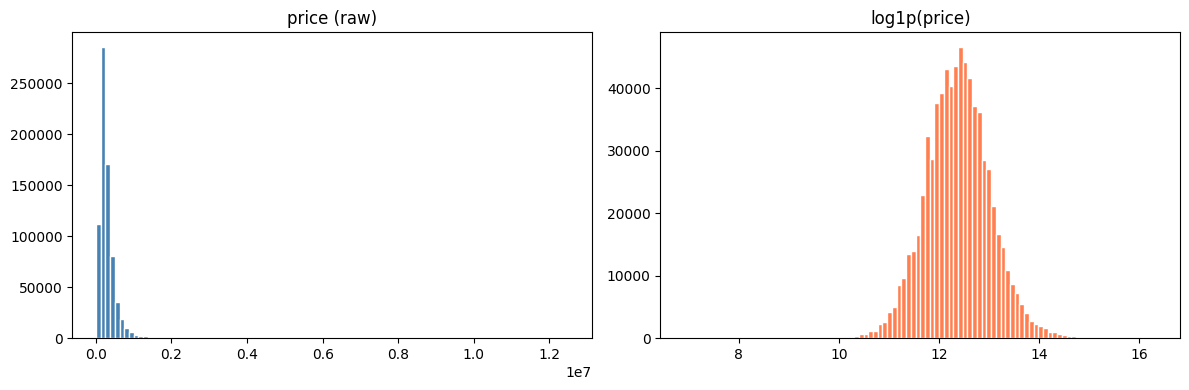

In [123]:
# Логарифмирование целевой переменной
# Price имеет сильно правостороннее распределение — log нормализует его
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('price (raw)')
axes[1].hist(df['log_price'], bins=100, color='coral', edgecolor='white')
axes[1].set_title('log1p(price)')
plt.tight_layout()
plt.show()

In [124]:
# Кодирование категориальных признаков — Label Encoding
# Используем для: Property_Type, postcode_area, County, Town/City
# (высокая кардинальность — One-Hot даст слишком много признаков)

cat_encode_cols = ['property_type', 'postcode_area', 'county', 'town/city']

le_encoders = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_encoders[col] = le
    print(f"{col}: {df[col].nunique()} уникальных значений")

print(df['town/city'].head())
df['town/city_enc'].head()

property_type: 4 уникальных значений
postcode_area: 106 уникальных значений
county: 113 уникальных значений
town/city: 1144 уникальных значений
0    SOUTHEND-ON-SEA
1              GRAYS
2         CHELMSFORD
3    SOUTHEND-ON-SEA
4         CHELMSFORD
Name: town/city, dtype: str


0    912
1    417
2    231
3    912
4    231
Name: town/city_enc, dtype: int64

In [125]:
# Итоговый набор признаков для модели
feature_cols = [
    # Временные
    'year', 'month', 'quarter',
    # Закодированные категориальные
    'property_type_enc', 'postcode_area_enc', 'county_enc', 'town/city_enc',
    # Бинарные флаги
    'is_new', 'is_freehold',
    # Географические медианы
    'county_median_price', 'postcode_district_median_price',
]

X = df[feature_cols].copy()
y_reg = df['log_price'].copy()       # для регрессии

print(f"Размер X: {X.shape}")
print(f"Признаки: {feature_cols}")

Размер X: (731321, 11)
Признаки: ['year', 'month', 'quarter', 'property_type_enc', 'postcode_area_enc', 'county_enc', 'town/city_enc', 'is_new', 'is_freehold', 'county_median_price', 'postcode_district_median_price']


In [126]:
# Целевая переменная для классификации
# 3 класса: низкая (<25%), средняя (25–75%), высокая (>75%)
q25 = df['price'].quantile(0.25)
q75 = df['price'].quantile(0.75)

print(f"Граница низкая/средняя: £{q25:,.0f}")
print(f"Граница средняя/высокая: £{q75:,.0f}")

def price_class(price):
    if price < q25:
        return 0  # низкая
    elif price <= q75:
        return 1  # средняя
    else:
        return 2  # высокая

y_clf = df['price'].apply(price_class)

print(f"\nРаспределение классов:")
print(y_clf.value_counts().sort_index().rename({0: 'Низкая', 1: 'Средняя', 2: 'Высокая'}))

Граница низкая/средняя: £155,000
Граница средняя/высокая: £356,000

Распределение классов:
price
Низкая     178306
Средняя    370200
Высокая    182815
Name: count, dtype: int64


In [127]:
# Train/Test split — 80/20, стратификация для классификации
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test:  {X_test.shape[0]} строк")

Train: 585056 строк
Test:  146265 строк


In [128]:
# Масштабирование (для линейных моделей)
# Fit только на train, transform на оба
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Масштабирование выполнено.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Масштабирование выполнено.
X_train_scaled shape: (585056, 11)
X_test_scaled shape:  (146265, 11)


In [129]:
# Итоговый чеклист перед обучением
print("=" * 50)
print("ДАННЫЕ ГОТОВЫ К ОБУЧЕНИЮ")
print("=" * 50)
print(f"Признаков: {len(feature_cols)}")
print(f"Train размер: {X_train.shape[0]}")
print(f"Test  размер: {X_test.shape[0]}")
print(f"\nДоступны:")
print(f"  X_train, X_test           — без масштабирования (для деревьев)")
print(f"  X_train_scaled, X_test_scaled — масштабированные (для линейных моделей)")
print(f"  y_reg_train, y_reg_test   — log1p(Price) для регрессии")
print(f"  y_clf_train, y_clf_test   — 0/1/2 для классификации")

ДАННЫЕ ГОТОВЫ К ОБУЧЕНИЮ
Признаков: 11
Train размер: 585056
Test  размер: 146265

Доступны:
  X_train, X_test           — без масштабирования (для деревьев)
  X_train_scaled, X_test_scaled — масштабированные (для линейных моделей)
  y_reg_train, y_reg_test   — log1p(Price) для регрессии
  y_clf_train, y_clf_test   — 0/1/2 для классификации
